# Лабораторная работа №1
## Настройка среды разработки и управление виртуальными окружениями

**Часть 1 (Anaconda) и Часть 3 (эксперимент на наборах данных)**

**Выполнил:** _Машканов Михаил Вячеславович_
**Группа:** _14_

**Среда выполнения:** Anaconda Distribution, Jupyter Notebook, ОС Windows 10 (x64).

**Цель работы:** освоение навыков развёртывания изолированных сред разработки, управления
пакетами через графический интерфейс (GUI) и терминал в Anaconda и Google Colaboratory,
а также первичный аудит аппаратных ресурсов.

> Часть 2 (Google Colaboratory) вынесена в отдельный блокнот `lab01_colab.ipynb`,
> поскольку выполняется в облачной среде.

# Лабораторная работа №1
## Настройка среды разработки и управление виртуальными окружениями

**Часть 1 (Anaconda) и Часть 3 (эксперимент на наборах данных)**

**Выполнил:** _Машканов Михаил Вячеславович_
**Группа:** _14_

**Среда выполнения:** Anaconda Distribution, Jupyter Notebook, ОС Windows 10 (x64).

**Цель работы:** освоение навыков развёртывания изолированных сред разработки, управления
пакетами через графический интерфейс (GUI) и терминал в Anaconda и Google Colaboratory,
а также первичный аудит аппаратных ресурсов.

> Часть 2 (Google Colaboratory) вынесена в отдельный блокнот `lab01_colab.ipynb`,
> поскольку выполняется в облачной среде.

---
# Часть 1. Работа в среде Anaconda (Jupyter Notebook)

## 1.1. Установка платформы

Дистрибутив Anaconda скачан с официального сайта (файл `Anaconda3-2026.07-1-Windows-x86_64.exe`)
и установлен в режиме **Just Me** в каталог `D:\PROGRAMM\anaconda3`.

Параметры, выбранные при установке:

* *Installation Type* — **Just Me** (установка не требует прав администратора);
* *Destination Folder* — `D:\PROGRAMM\anaconda3` — путь без пробелов и кириллицы,
  это требование conda: в противном случае часть post-link скриптов пакетов завершается ошибкой;
* *Register Anaconda3 as my default Python* — включено;
* *Add Anaconda to my PATH* — выключено (вариант, рекомендованный разработчиком);
  вместо изменения `PATH` используется ярлык **Anaconda Prompt**, который активирует
  окружение только в своём сеансе.

Ниже программно подтверждается факт установки и выводятся параметры платформы.

In [1]:
import sys, os, platform, subprocess
from pathlib import Path

# Корень установки Anaconda определяется от текущего интерпретатора:
# активное окружение располагается в <anaconda_root>\envs\<env_name>
ENV_PREFIX = Path(sys.prefix)
ANACONDA_ROOT = ENV_PREFIX.parents[1] if ENV_PREFIX.parent.name == "envs" else ENV_PREFIX
CONDA_EXE = Path(os.environ.get("CONDA_EXE") or ANACONDA_ROOT / "Scripts" / "conda.exe")


def conda(*args: str) -> str:
    """Вызвать conda из блокнота и вернуть текстовый вывод."""
    res = subprocess.run([str(CONDA_EXE), *args],
                         capture_output=True, text=True, encoding="utf-8", errors="replace")
    return (res.stdout or "") + (res.stderr or "")


print("Операционная система :", platform.platform())
print("Разрядность Python   :", platform.architecture()[0])
print()
print("Корень Anaconda      :", ANACONDA_ROOT)
print("Активное окружение   :", ENV_PREFIX)
print("Имя окружения        :", os.environ.get("CONDA_DEFAULT_ENV", ENV_PREFIX.name))
print("Интерпретатор Python :", sys.executable)
print("Версия Python        :", sys.version.split()[0])
print()
print("Версия пакетного менеджера:", conda("--version").strip())

Операционная система : Windows-10-10.0.19045-SP0
Разрядность Python   : 64bit

Корень Anaconda      : D:\PROGRAMM\anaconda3
Активное окружение   : D:\PROGRAMM\anaconda3\envs\lab1_terminal
Имя окружения        : lab1_terminal
Интерпретатор Python : D:\PROGRAMM\anaconda3\envs\lab1_terminal\python.exe
Версия Python        : 3.12.14

Версия пакетного менеджера: conda 26.7.2


## 1.2. Управление виртуальными окружениями

Виртуальное окружение conda — это изолированный каталог внутри `<anaconda_root>\envs\`
с собственным интерпретатором Python и собственным набором библиотек. Изоляция позволяет
держать для разных задач несовместимые версии пакетов и не нарушать работоспособность
базового окружения `base`.

По условию работы окружение требуется создать **двумя способами** — через графический
интерфейс Anaconda Navigator и через терминал Anaconda Prompt.

| Окружение | Способ создания | Назначение |
|---|---|---|
| `lab1_gui` | Anaconda Navigator (GUI) | демонстрация работы с окружениями через графический интерфейс |
| `lab1_terminal` | Anaconda Prompt (`conda create`) | рабочее окружение, в котором выполняется данный блокнот |

### 1.2.1. Создание и активация окружения через GUI (Anaconda Navigator)

Последовательность действий в Anaconda Navigator:

1. Запуск **Anaconda Navigator**: меню «Пуск» → *Anaconda (anaconda3)* → *Anaconda Navigator*.
2. Переход на вкладку **Environments** в левой панели — открывается список существующих окружений.
3. Нажатие кнопки **Create** в нижней части окна.
4. В диалоге *Create new environment* указано имя окружения `lab1_gui`, в списке *Packages*
   отмечен **Python** версии **3.12**; нажата кнопка **Create**.
5. Окружение появилось в списке. **Активация через GUI** выполняется щелчком по имени
   окружения: Navigator помечает его как активное, и все последующие операции — установка
   пакетов, запуск приложений с вкладки *Home* — выполняются уже в нём.
6. Запуск терминала непосредственно в этом окружении: щелчок по треугольнику справа от имени
   окружения → **Open Terminal** (открывается консоль с уже активированным `lab1_gui`).

![Создание окружения lab1_gui в Anaconda Navigator](images/01_navigator_create_env.png)

![Окружение lab1_gui активировано](images/02_navigator_env_active.png)

### 1.2.2. Создание и активация окружения через терминал (Anaconda Prompt)

В меню «Пуск» запущен **Anaconda Prompt**, в нём выполнены команды:

```bat
:: создание изолированного окружения с указанной версией Python и набором пакетов
conda create -n lab1_terminal python=3.12 numpy pandas matplotlib seaborn scikit-learn jupyter notebook ipykernel -y

:: активация созданного окружения
conda activate lab1_terminal

:: проверка того, какой интерпретатор стал активным
python -c "import sys; print(sys.executable)"
```

После активации приглашение командной строки меняется с `(base)` на `(lab1_terminal)` —
это визуальный признак того, что окружение активно.

Чтобы созданное окружение стало доступно как **ядро (kernel)** Jupyter Notebook,
в нём дополнительно выполнена регистрация ядра:

```bat
python -m ipykernel install --prefix D:\PROGRAMM\anaconda3 --name lab1_terminal --display-name "Python (lab1_terminal)"
```

Полный протокол выполнения `conda create` сохранён в файле
[`logs/conda_create_lab1_terminal.log`](logs/conda_create_lab1_terminal.log).

![Создание и активация окружения через Anaconda Prompt](images/03_prompt_create_activate.png)

### 1.2.3. Программная проверка созданных окружений

Убедимся, что оба окружения действительно созданы и что текущий блокнот выполняется
именно в изолированном окружении `lab1_terminal`, а не в базовом `base`.

In [2]:
print(conda("env", "list"))

active = os.environ.get("CONDA_DEFAULT_ENV", ENV_PREFIX.name)
print("Блокнот выполняется в окружении :", active)
print("Изолированный интерпретатор     :", sys.executable)

assert ENV_PREFIX.parent.name == "envs", "Блокнот должен выполняться в изолированном окружении, а не в base"
print("\nПроверка пройдена: блокнот работает в изолированном виртуальном окружении.")


# conda environments:
#
# * -> active
# + -> frozen
base                     D:\PROGRAMM\anaconda3
lab1_gui                 D:\PROGRAMM\anaconda3\envs\lab1_gui
lab1_terminal        *   D:\PROGRAMM\anaconda3\envs\lab1_terminal
ml                       D:\PROGRAMM\anaconda3\envs\ml


Блокнот выполняется в окружении : lab1_terminal
Изолированный интерпретатор     : D:\PROGRAMM\anaconda3\envs\lab1_terminal\python.exe

Проверка пройдена: блокнот работает в изолированном виртуальном окружении.


## 1.3. Установка библиотек и аудит версий

### 1.3.1. Установка пакетов через GUI (Anaconda Navigator)

В Anaconda Navigator на вкладке **Environments** для окружения `lab1_gui`:

1. В выпадающем списке фильтра пакетов выбрано значение **Not installed**.
2. В поле **Search Packages** последовательно введены имена `numpy`, `pandas`, `matplotlib`,
   `seaborn`, `scikit-learn`; напротив каждого найденного пакета установлен флажок.
3. Нажата кнопка **Apply**. Navigator показал окно *Install Packages* со списком зависимостей,
   которые будут добавлены; установка подтверждена кнопкой **Apply**.
4. После завершения установки фильтр переключён обратно на **Installed** — все пять пакетов
   присутствуют в списке с указанием номеров версий.

![Установка пакетов через менеджер пакетов Navigator](images/04_navigator_install_packages.png)

### 1.3.2. Установка пакетов через терминал

Те же пакеты в окружении `lab1_terminal` устанавливаются командой `conda install`
(в данном случае они были перечислены сразу при создании окружения, поэтому команда
подтверждает, что все требования уже удовлетворены):

```bat
conda activate lab1_terminal
conda install numpy pandas matplotlib seaborn scikit-learn -y
```

Для пакетов, отсутствующих в основном канале, используется канал `conda-forge`:

```bat
conda install -c conda-forge <имя_пакета> -y
```

### 1.3.3. Программное определение версий пакетов

Версии определяются непосредственно из работающего интерпретатора: выполняется импорт
каждой библиотеки и чтение её атрибута `__version__`. Такой способ надёжнее чтения списка
пакетов, поскольку показывает именно то, что реально доступно ядру блокнота.

In [3]:
import importlib

REQUIRED = [
    ("numpy",        "numpy"),
    ("pandas",       "pandas"),
    ("matplotlib",   "matplotlib"),
    ("seaborn",      "seaborn"),
    ("scikit-learn", "sklearn"),
]

rows = []
for dist_name, import_name in REQUIRED:
    try:
        module = importlib.import_module(import_name)
        rows.append({"Пакет": dist_name, "Имя при импорте": import_name,
                     "Статус": "установлен", "Версия": getattr(module, "__version__", "н/д")})
    except ImportError:
        rows.append({"Пакет": dist_name, "Имя при импорте": import_name,
                     "Статус": "НЕ УСТАНОВЛЕН", "Версия": "-"})

import pandas as pd

versions = pd.DataFrame(rows)
print("Аудит базовых пакетов анализа данных в окружении:",
      os.environ.get("CONDA_DEFAULT_ENV", ENV_PREFIX.name))
print()
versions

Аудит базовых пакетов анализа данных в окружении: lab1_terminal



,Пакет,Имя при импорте,Статус,Версия
0,numpy,numpy,установлен,2.5.3
1,pandas,pandas,установлен,3.0.6
2,matplotlib,matplotlib,установлен,3.11.2
3,seaborn,seaborn,установлен,0.13.2
4,scikit-learn,sklearn,установлен,1.9.1


In [4]:
# Тот же аудит средствами стандартной библиотеки importlib.metadata:
# версии берутся из метаданных дистрибутивов, а не из атрибутов модулей.
from importlib.metadata import version, PackageNotFoundError

for dist_name, _ in REQUIRED:
    try:
        print(f"{dist_name:<14} {version(dist_name)}")
    except PackageNotFoundError:
        print(f"{dist_name:<14} не найден")

numpy          2.5.3
pandas         3.0.6
matplotlib     3.11.2
seaborn        0.13.2
scikit-learn   1.9.1


### 1.3.4. Полный список пакетов окружения

Команда `conda list`, выполненная в терминале активированного окружения, выводит полный
перечень установленных пакетов с версиями, номерами сборок и каналом установки:

```bat
conda activate lab1_terminal
conda list
```

Полный вывод сохранён в файле
[`logs/conda_list_lab1_terminal.txt`](logs/conda_list_lab1_terminal.txt).
Ниже та же команда вызывается программно из блокнота; для компактности показаны
первые строки вывода и итоговое количество пакетов.

In [5]:
full_list = conda("list", "-n", "lab1_terminal")
lines = [ln for ln in full_list.splitlines() if ln.strip()]
header = [ln for ln in lines if ln.startswith("#")]
packages = [ln for ln in lines if not ln.startswith("#")]

print("\n".join(header))
print("\n".join(packages[:25]))
print("...")
print(f"\nВсего установлено пакетов в окружении lab1_terminal: {len(packages)}")

# packages in environment at D:\PROGRAMM\anaconda3\envs\lab1_terminal:
#
# Name                       Version          Build                  Channel
_openmp_mutex                2.0              52_msvc
anyio                        4.15.1           py312haa95532_0
aom                          3.14.0           h1653897_0
argon2-cffi                  25.1.0           py312haa95532_0
argon2-cffi-bindings         25.1.0           py312h02ab6af_0
asttokens                    3.0.1            py312haa95532_0
async-lru                    2.3.0            py312haa95532_0
attrs                        26.1.0           py312h35db113_0
babel                        2.18.0           py312haa95532_0
beautifulsoup4               4.15.0           py312haa95532_0
blas                         1.0              mkl
bleach                       6.4.0            py312haa95532_0
brotlicffi                   1.2.0.1          py312hd7fb8db_0
bzip2                        1.0.8            h2bbff1b_6
ca-certifica

---
# Часть 3. Экспериментальная проверка на наборах данных

Для проверки работоспособности собранного окружения используются **два различных набора
данных**. Оба загружаются средствами `pandas` из локальных CSV-файлов каталога `data/`,
после чего для каждого строится график средствами `seaborn`/`matplotlib`.

| Набор данных | Файл | Объектов | Содержание |
|---|---|---|---|
| Fisher's Iris | `data/iris.csv` | 150 | морфометрия цветков ириса трёх видов |
| Titanic | `data/titanic.csv` | 891 | сведения о пассажирах «Титаника» и факт спасения |

Наборы намеренно выбраны разнородными: первый — «чистая» числовая таблица без пропусков,
второй содержит категориальные признаки и пропущенные значения.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_DIR = Path("data")
print("Каталог с данными:", DATA_DIR.resolve())
print("Файлы             :", [p.name for p in sorted(DATA_DIR.glob("*.csv"))])

Каталог с данными: D:\Misha\Универ\ДП2\lab01\data
Файлы             : ['iris.csv', 'titanic.csv']


## 3.1. Набор данных №1 — Fisher's Iris

Классический набор для задач классификации: 150 наблюдений, четыре числовых признака
(длина и ширина чашелистика и лепестка) и метка вида растения.

In [7]:
iris = pd.read_csv(DATA_DIR / "iris.csv")

print("Размерность (строк, столбцов):", iris.shape)
print()
iris.head()

Размерность (строк, столбцов): (150, 5)



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
print("Типы данных и заполненность:")
iris.info()

print()
print("Распределение объектов по видам:")
print(iris["species"].value_counts().to_string())

print()
print("Описательные статистики числовых признаков:")
iris.describe().round(2)

Типы данных и заполненность:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Распределение объектов по видам:
species
setosa        50
versicolor    50
virginica     50

Описательные статистики числовых признаков:


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


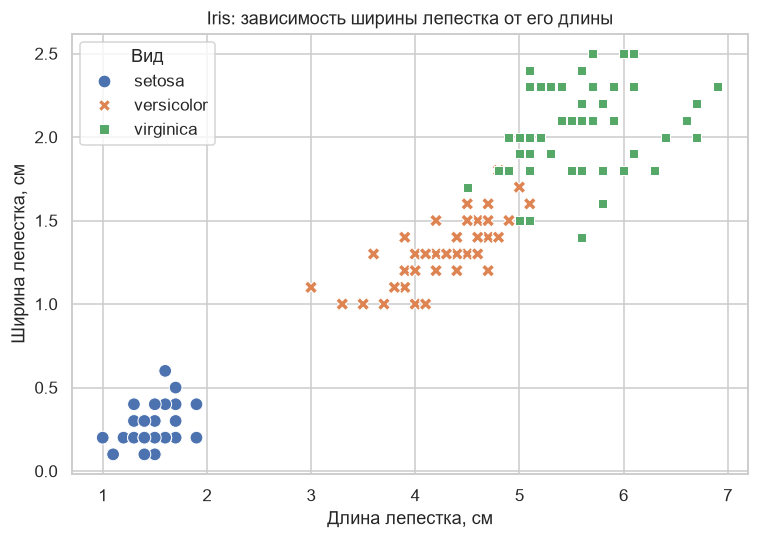

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=iris, x="petal_length", y="petal_width",
                hue="species", style="species", s=70, ax=ax)

ax.set_title("Iris: зависимость ширины лепестка от его длины")
ax.set_xlabel("Длина лепестка, см")
ax.set_ylabel("Ширина лепестка, см")
ax.legend(title="Вид")

fig.tight_layout()
plt.show()

**Вывод по набору Iris.** График показывает, что вид *setosa* линейно отделим от двух
остальных по признакам лепестка, тогда как *versicolor* и *virginica* частично перекрываются.
Данные корректно прочитаны `pandas`, график построен `seaborn`/`matplotlib` — связка библиотек
в окружении работоспособна.

## 3.2. Набор данных №2 — Titanic

Набор с разнородными типами данных: числовые признаки (возраст, стоимость билета),
категориальные (пол, класс каюты, порт посадки) и пропущенные значения — то есть материал,
на котором проверяется работа `pandas` не только с «чистой» числовой таблицей.

In [10]:
titanic = pd.read_csv(DATA_DIR / "titanic.csv")

print("Размерность (строк, столбцов):", titanic.shape)
print()
titanic.head()

Размерность (строк, столбцов): (891, 15)



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
print("Пропущенные значения по столбцам (показаны только непустые):")
missing = titanic.isna().sum()
print(missing[missing > 0].to_string())

print()
print("Доля выживших в разрезе класса каюты и пола:")
pivot = titanic.pivot_table(index="class", columns="sex", values="survived",
                            aggfunc="mean", observed=False).round(3)
pivot

Пропущенные значения по столбцам (показаны только непустые):
age            177
embarked         2
deck           688
embark_town      2

Доля выживших в разрезе класса каюты и пола:


sex,female,male
class,,
First,0.968,0.369
Second,0.921,0.157
Third,0.500,0.135


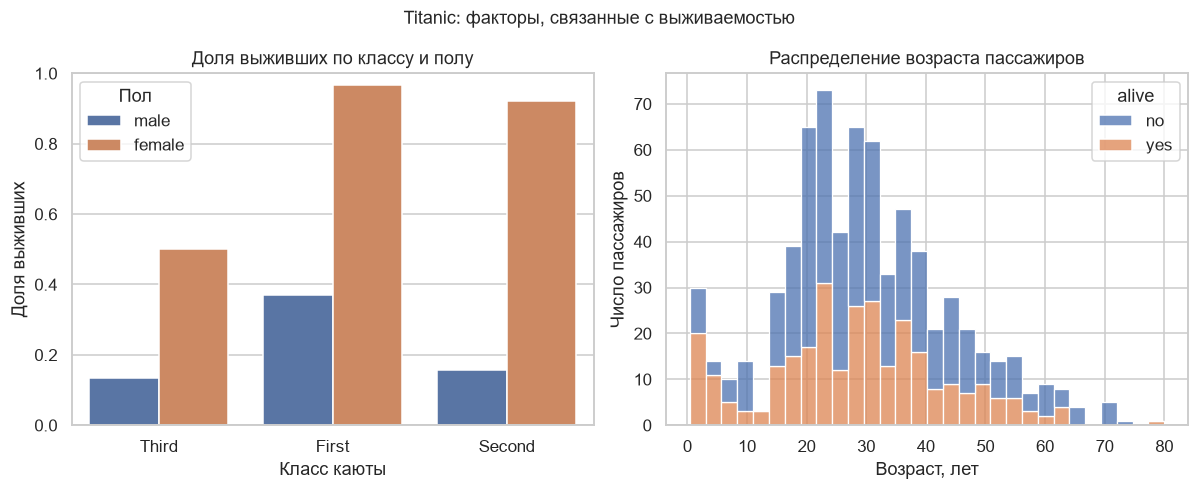

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=titanic, x="class", y="survived", hue="sex",
            errorbar=None, ax=axes[0])
axes[0].set_title("Доля выживших по классу и полу")
axes[0].set_xlabel("Класс каюты")
axes[0].set_ylabel("Доля выживших")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Пол")

sns.histplot(data=titanic, x="age", hue="alive", bins=30,
             multiple="stack", ax=axes[1])
axes[1].set_title("Распределение возраста пассажиров")
axes[1].set_xlabel("Возраст, лет")
axes[1].set_ylabel("Число пассажиров")

fig.suptitle("Titanic: факторы, связанные с выживаемостью")
fig.tight_layout()
plt.show()

**Вывод по набору Titanic.** Доля выживших резко различается по полу и классу каюты:
у женщин первого класса она близка к единице, у мужчин третьего — минимальна. `pandas`
корректно обработал пропуски в столбце `age` при построении гистограммы, сводная таблица
`pivot_table` отработала на категориальных признаках. Окружение подтвердило работоспособность
на данных с неоднородной структурой.

---
# Выводы

1. Дистрибутив **Anaconda** установлен в каталог `D:\PROGRAMM\anaconda3` в режиме *Just Me*;
   работоспособность платформы подтверждена программно — выведены версия conda, версия Python
   и путь к интерпретатору.
2. Освоено создание изолированных виртуальных окружений **двумя способами**: через графический
   интерфейс **Anaconda Navigator** (окружение `lab1_gui`) и через терминал **Anaconda Prompt**
   командами `conda create` и `conda activate` (окружение `lab1_terminal`). Программная проверка
   подтвердила, что блокнот выполняется в изолированном окружении, а не в `base`.
3. Освоена установка библиотек обоими способами — через менеджер пакетов Navigator
   (фильтр *Not installed* → выбор пакетов → *Apply*) и через терминал (`conda install`).
   Наличие и версии пакетов `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`
   определены программно двумя независимыми методами: через атрибут `__version__` модуля
   и через `importlib.metadata`. Полный список пакетов окружения получен командой `conda list`.
4. Работоспособность собранного окружения подтверждена на **двух различных наборах данных**
   (Iris и Titanic): выполнена загрузка через `pandas` и построены графики средствами
   `seaborn`/`matplotlib`, включая обработку категориальных признаков и пропущенных значений.
5. Часть 2 работы, посвящённая **Google Colaboratory** и аппаратным ускорителям (GPU/TPU),
   выполнена в отдельном блокноте `lab01_colab.ipynb`.